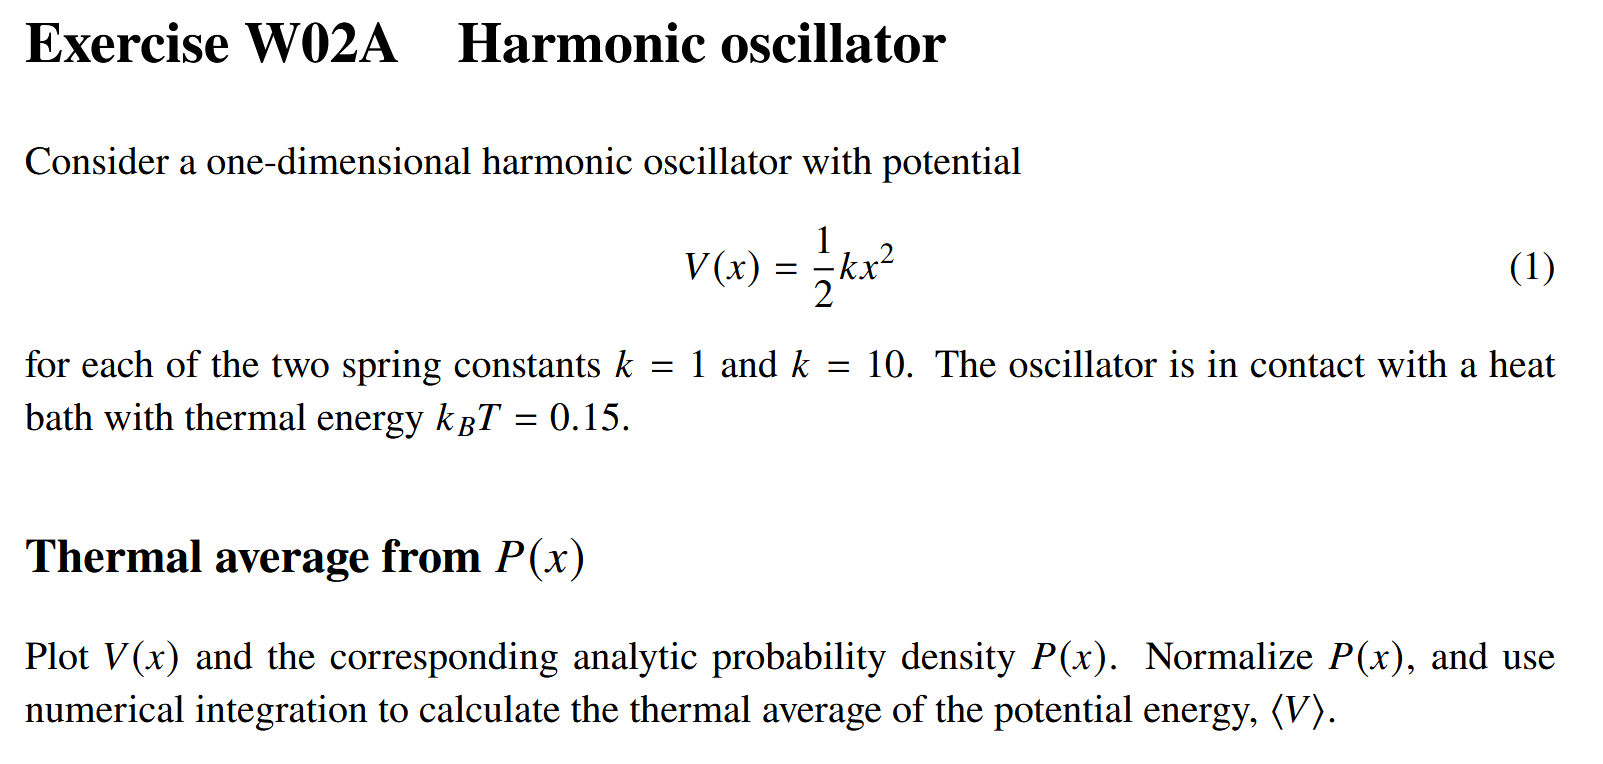
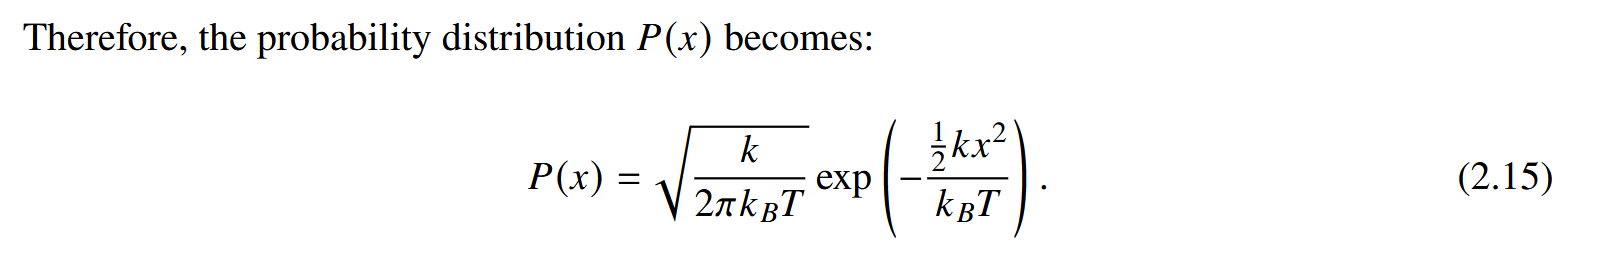

<V> using quad: 0.075 ± 7.08e-11
Using <V>=1/2 * k_bT = 0.075
Integral of P(x): (1.0000000000000049, 5.774218592933101e-10)
<V> using quad: 0.075 ± 1.28e-08
Using <V>=1/2 * k_bT = 0.075
Integral of P(x): (0.9999999999999999, 3.906787805256202e-09)


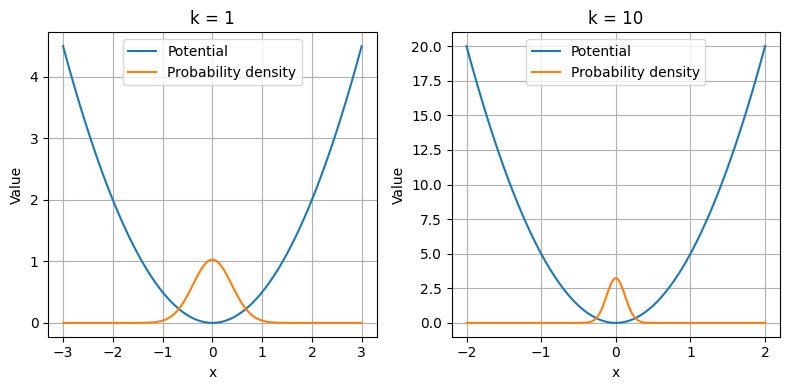

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import quad

class HarmonicOscilator:
    def __init__(self, k=1, x0=0, kbT=0.15, xmin=-3, xmax=3, verbose=False):
        self.k = k
        self.x0 = x0
        self._sample = None
        self.kbT = kbT
        self.xmin = xmin
        self.xmax = xmax
        self.verbose = verbose

    def V(self, x):
        return (0.5*self.k*(x-self.x0)**2) 

    def P(self, x): 
        return np.sqrt(self.k/(2*np.pi*self.kbT))*np.exp(-self.V(x)/self.kbT)

    def expect_V(self):
        return quad(lambda x_in: self.V(x_in)*self.P(x_in), -np.inf, np.inf)

    def expect_V_squared(self):
        return quad(lambda x_in: self.V(x_in)**2*self.P(x_in), -np.inf, np.inf)

    def plot(self, ax):
        x = np.linspace(self.xmin, self.xmax, 100)

        ax.plot(x, self.V(x), label="Potential")
        ax.plot(x, self.P(x), label="Probability density")
        ax.set_title(f"k = {self.k}")
        ax.set_xlabel("x")
        ax.set_ylabel("Value")
        ax.legend()
        ax.grid()

        expect_V = self.expect_V()
        print(f"<V> using quad: {expect_V[0]:.3g} ± {expect_V[1]:.3g}")
        print(f"Using <V>=1/2 * k_bT = {0.5*self.kbT}")
        if self.verbose:
            print(f"Integral of P(x): {quad(self.P, -np.inf, np.inf)}")


    
L = [HarmonicOscilator(k=1, verbose=True), HarmonicOscilator(k=10, xmin=-2, xmax=2, verbose=True)]
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

for i, ax in zip(L, axs):
    i.plot(ax)

plt.tight_layout()
plt.show()


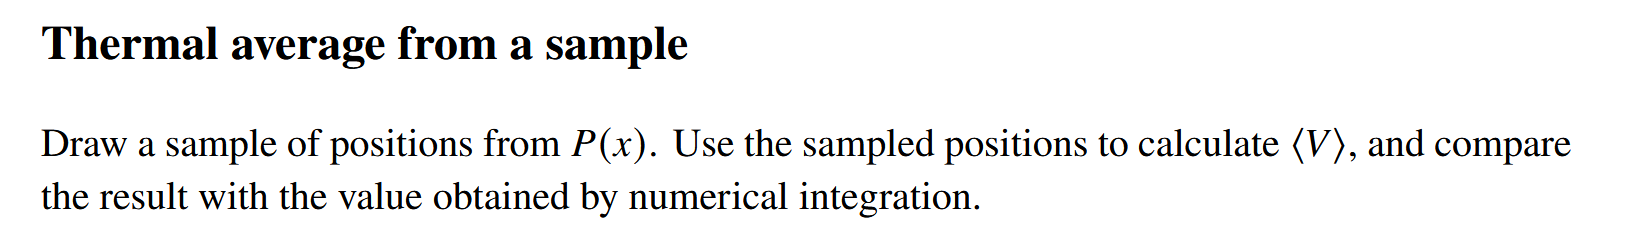


For k=1 we get: 
Using sampling <V> = 0.0749
<V> using quad: 0.075 ± 7.08e-11
Using <V>=1/2 * k_bT = 0.075

For k=10 we get: 
Using sampling <V> = 0.0756
<V> using quad: 0.075 ± 1.28e-08
Using <V>=1/2 * k_bT = 0.075


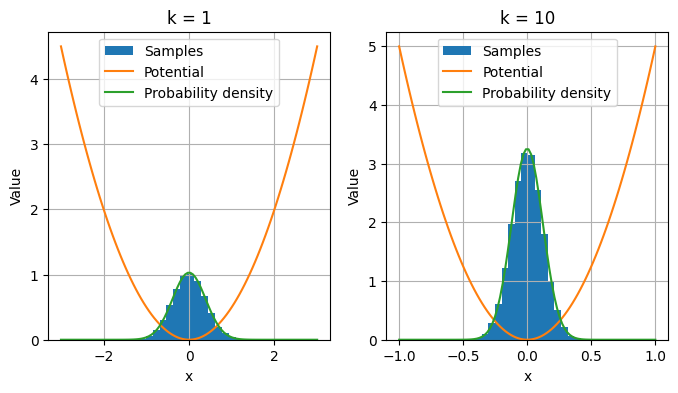

In [82]:
class HarmonicOscilator(HarmonicOscilator):
    def sample(self, N=100_000):
        xs = np.linspace(self.xmin, self.xmax, N)
        accept = lambda x: np.exp(-0.5*self.k*(x-self.x0)**2/self.kbT)
        self._sample = np.array([x for x in xs if np.random.rand() < accept(x)])
        if self.verbose: 
            print(f"Sample size: {len(self._sample)}")

    def potential_from_sample(self, N=100_000):
        if self._sample == None:
            self.sample(N)
        out = np.sum(self.V(self._sample))/len(self._sample)
        print(f"Using sampling <V> = {out:.3g}")
        return out

    def histogram(self, ax):
        ax.hist(self._sample, 20, density=True, label="Samples")
        self.plot(ax)

L = [HarmonicOscilator(k=1), HarmonicOscilator(k=10, xmin=-1, xmax=1)]
fig, axs = plt.subplots(1, 2, figsize=(8,4))

for i, ax in zip(L, axs):
    print(f"\nFor k={i.k} we get: ")
    i.potential_from_sample()
    i.histogram(ax)


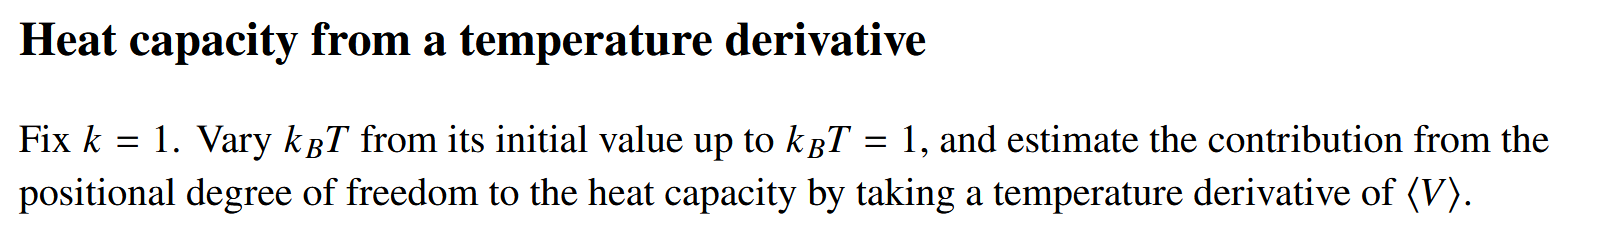

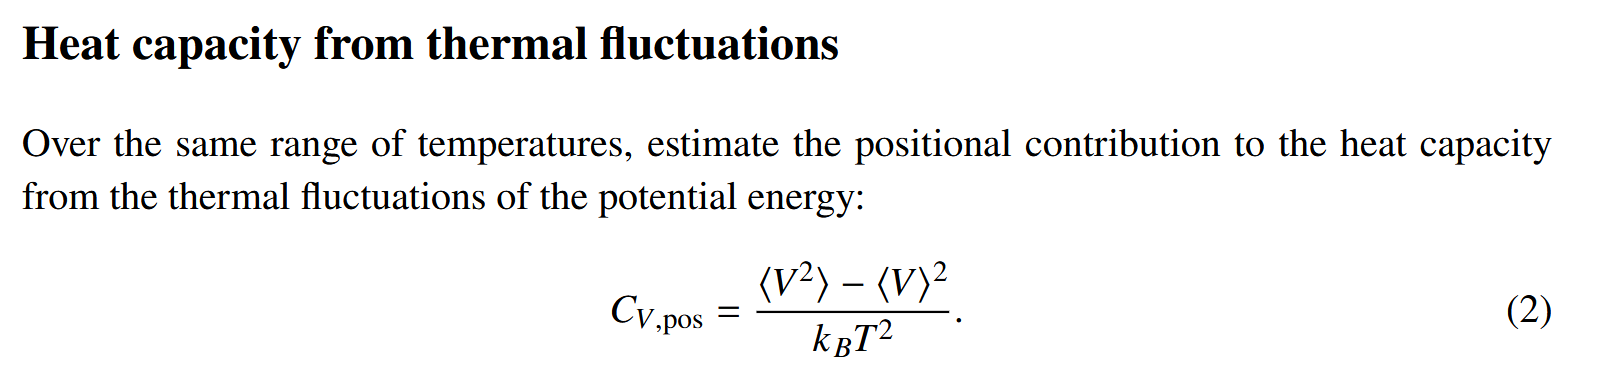


k_bT=0.15
Using sampling <V> = 0.0746
<V> using quad: 0.075 ± 7.08e-11
Using <V>=1/2 * k_bT = 0.075

k_bT=0.3
Using sampling <V> = 0.15
<V> using quad: 0.15 ± 7.44e-11
Using <V>=1/2 * k_bT = 0.15

k_bT=0.4
Using sampling <V> = 0.202
<V> using quad: 0.2 ± 4.4e-10
Using <V>=1/2 * k_bT = 0.2

k_bT=0.8
Using sampling <V> = 0.398
<V> using quad: 0.4 ± 1.05e-08
Using <V>=1/2 * k_bT = 0.4

k_bT=1.0
Using sampling <V> = 0.485
<V> using quad: 0.5 ± 8.24e-09
Using <V>=1/2 * k_bT = 0.5


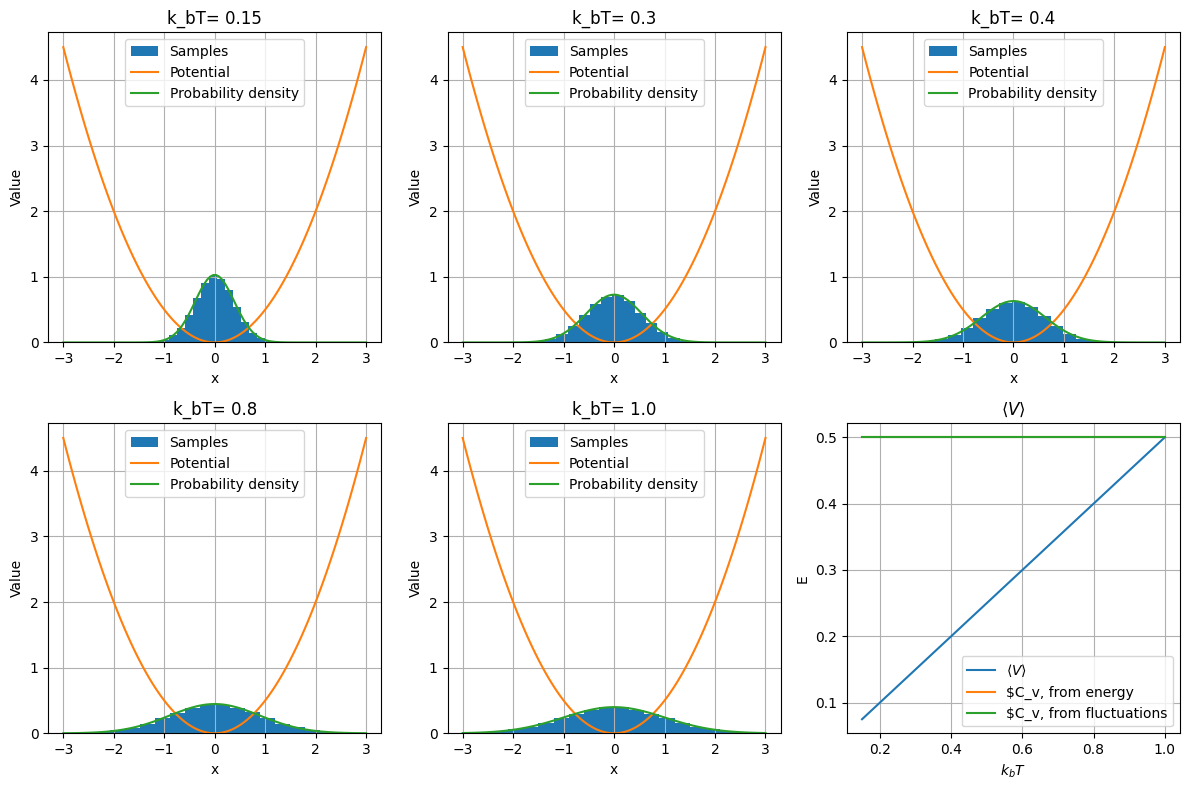

In [98]:
k_bT = np.array([0.15, 0.3, 0.4, 0.8, 1.0])
exp_V = []
exp_V_sq = []
n = len(k_bT)

fig, axs = plt.subplots(2, 3, figsize=(12, 8))
axs = axs.flatten()

for k, ax in zip(k_bT, axs[:-1]): 
    print(f"\n{r"k_bT"}={k}")
    pot = HarmonicOscilator(k=1, kbT=k)
    pot.potential_from_sample()
    exp_V.append(pot.expect_V()[0])
    exp_V_sq.append(pot.expect_V_squared()[0])
    pot.histogram(ax)
    ax.set_title(r"k_bT="+f" {k}")

exp_V = np.array(exp_V)
exp_V_sq = np.array(exp_V_sq)

ax = axs[-1]
ax.plot(k_bT, exp_V, label=r"$\langle V \rangle$")
ax.plot(k_bT, exp_V/k_bT, label=r"$C_v, from energy")
ax.plot(k_bT, (exp_V_sq-exp_V**2)/k_bT**2, label=r"$C_v, from fluctuations")
ax.set_title(r"$\langle V \rangle$")
ax.set_xlabel(r"$k_bT$")
ax.set_ylabel("E")
ax.grid()
ax.legend()
plt.tight_layout()